# Snow metrics publication figures

Plot saved snow-metrics NetCDFs and MOD10A1 observation CSVs.

Prerequisite: run `water_year_snow_metrics_to_netcdf.ipynb` (or the Snakemake workflow) to produce `{catchment}_{source}_snow_metrics.nc` files.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

workflow_dir = Path("../../").resolve()
sys.path.insert(0, str(workflow_dir / "scripts"))

import compute_water_year_snow_metrics as wysm
from snow_metrics_publication_plot import plot_snow_metrics_publication
from snow_metrics_spatial_plot import plot_spatial_model_obs_panel
from summa_postprocess_specs import build_output_nc_manifest

%reload_ext autoreload
%autoreload 2


In [6]:
# --- Configuration ---
catchments = [
    "chena",
    "bow",
    "tuolumne",
]

gpep_root = Path("/anvil/projects/x-ees240082/users/dcasson/gpep")

plot_start_year = 2009  # None = no lower bound
plot_end_year = 2018    # None = no upper bound

_publication_dir = Path("/home/x-dcasson/GitRepos/gpep_to_summa_snakemake/workflow/gee")
include_obs_csv = True
obs_csv_label = "MOD10A1"
obs_csv_by_catchment: dict[str, Path | None] = {
    "chena": _publication_dir / "SnowMetrics_chena.csv",
    "bow": _publication_dir / "SnowMetrics_bow.csv",
    "tuolumne": _publication_dir / "SnowMetrics_tuolumne.csv",
}

output_nc_by_catchment = build_output_nc_manifest(
    catchments,
    product="snow_metrics",
    gpep_root=gpep_root,
)


### Time series (SDD and SCF)


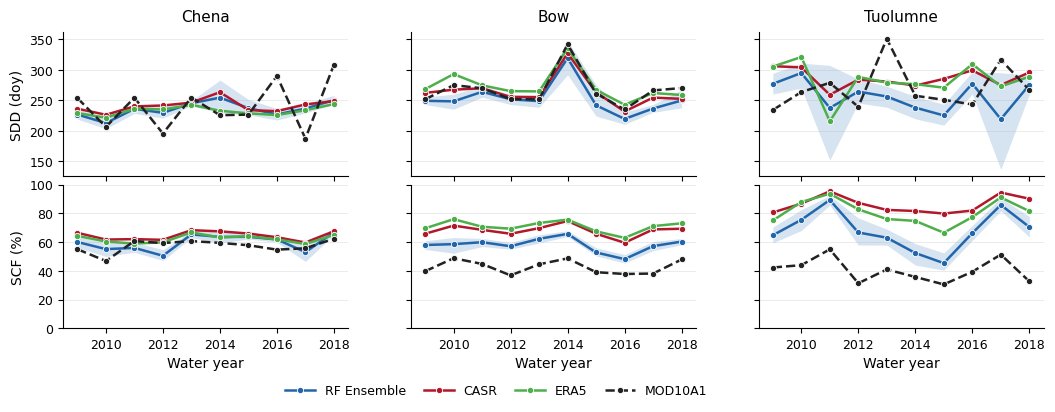

In [7]:
fig, axes = plot_snow_metrics_publication(
    output_nc_by_catchment,
    #source_labels = ["RF Ensemble"],
    vars=(
        wysm.VAR_SNOW_DISAPPEARANCE,
        wysm.VAR_SCF_DAYS,
    ),
    default_start_year=plot_start_year,
    default_end_year=plot_end_year,
    include_obs=include_obs_csv,
    obs_csv_by_catchment=obs_csv_by_catchment,
    obs_label=obs_csv_label,
)
plt.show()


### Spatial comparison — SCF (RF Ensemble, MOD10A1, difference)


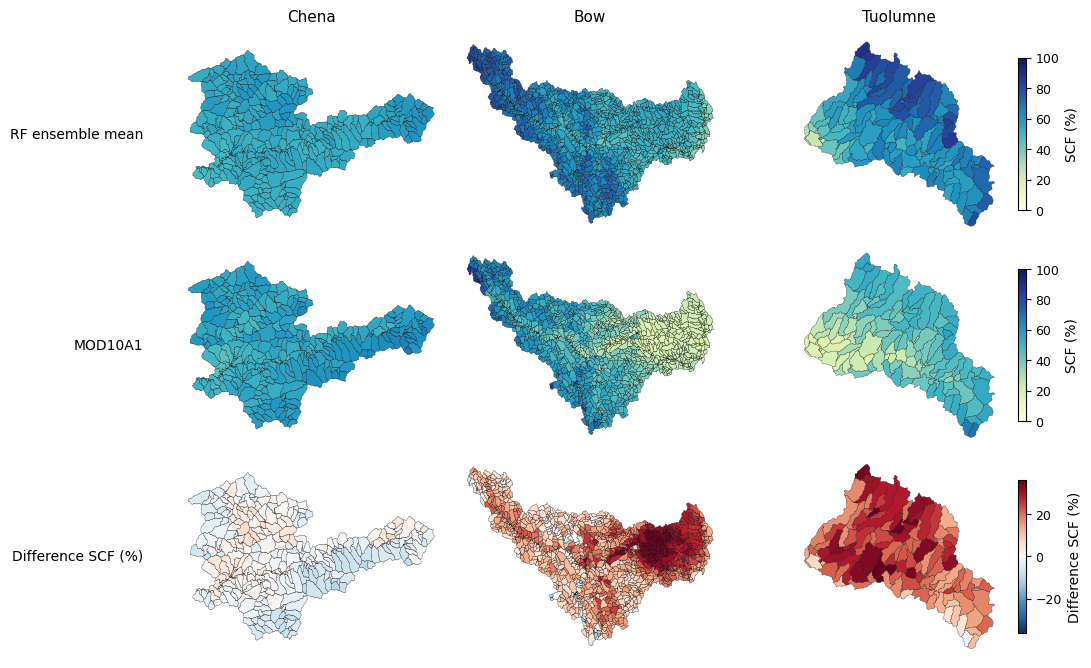

In [8]:
fig, axes, panel_gdfs = plot_spatial_model_obs_panel(
    output_nc_by_catchment,
    obs_csv_by_catchment,
    model_label="RF Ensemble",
    catchments_list=catchments,
    gpep_root=gpep_root,
    obs_label=obs_csv_label,
    var=wysm.VAR_SCF_DAYS,
)
plt.show()


### Spatial comparison — SDD (RF Ensemble and difference)


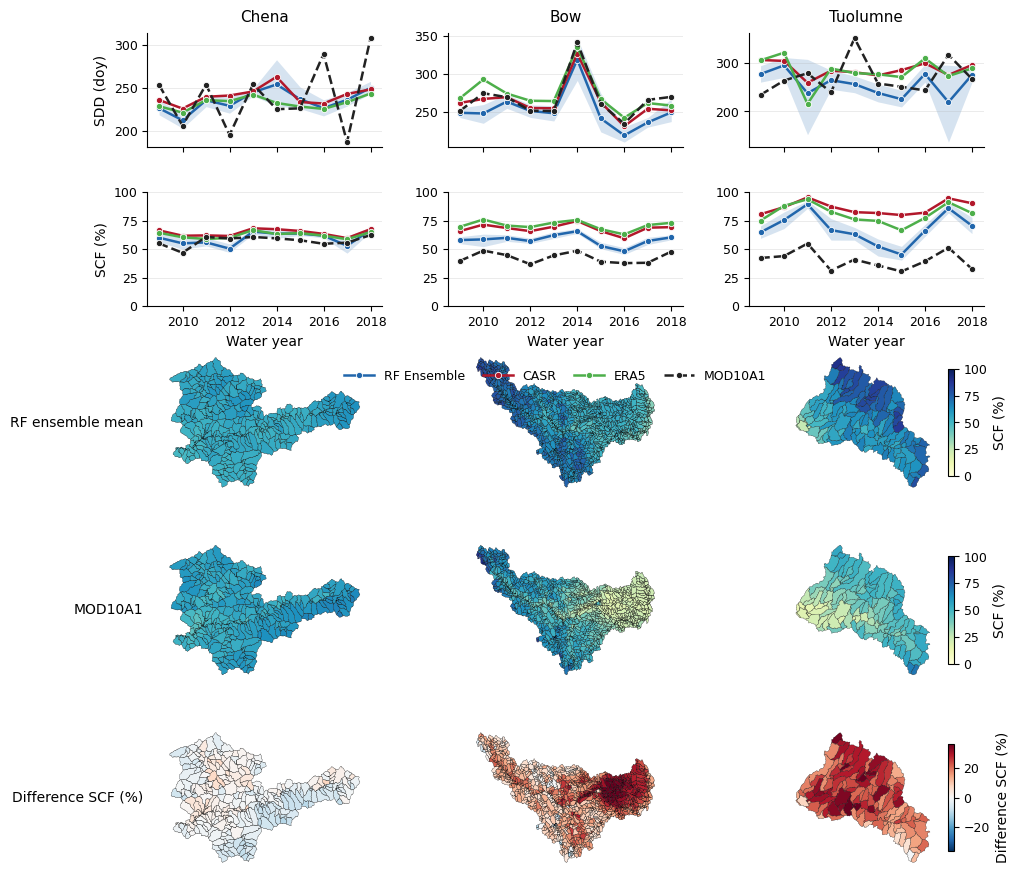

In [9]:
fig, axes, panel_gdfs = plot_spatial_model_obs_panel(
    output_nc_by_catchment,
    obs_csv_by_catchment,
    model_label="RF Ensemble",
    catchments_list=catchments,
    gpep_root=gpep_root,
    var=wysm.VAR_SNOW_DISAPPEARANCE,
    include_obs_row=False,
)
plt.show()
